In [1]:
using Pkg
Pkg.activate(normpath(joinpath(@__DIR__, "..")))

  Activating project at `~/DART`


In [2]:
using PyPlot, JLD2, Statistics

const np = PyPlot.pyimport("numpy");
# to obtain probability of histogram through np.histogram

#### Fig S11

In [4]:
data_dir = "synthetic_data/ideal_data_res"

# calculate the mean for each seed
function metrics_from_file(path::AbstractString)
    @load path rn_met_dl
    acc  = mean(m.acc for m in rn_met_dl)
    res1 = mean(abs(m.binart_mean[1] - m.truet_mean[1]) / m.truet_mean[1] for m in rn_met_dl)
    res2 = mean(abs(m.binart_mean[2] - m.truet_mean[2]) / m.truet_mean[2] for m in rn_met_dl)
    return (acc, res1, res2)
end

function collect_metrics(model_name::AbstractString; nseeds::Int=50, data_dir::AbstractString=data_dir)
    accs  = Float64[]; res1s = Float64[]; res2s = Float64[]
    for s in 1:nseeds
        file = joinpath(data_dir, "mgen_dl$(model_name)_compare_seed_$(s).jld2")
        acc, r1, r2 = metrics_from_file(file)
        push!(accs, acc); push!(res1s, r1); push!(res2s, r2)
    end
    return (accs=accs, res1=res1s, res2=res2s)
end

models = ["b33", "b333", "nb133", "nb1333", "nb033", "nb0333"]

# save results into a dictionary：model_name => (accs=..., res1=..., res2=...)
results = Dict(m => collect_metrics(m) for m in models)

accs_b33   = results["b33"].accs;   res1_b33   = results["b33"].res1;   res2_b33   = results["b33"].res2
accs_b333  = results["b333"].accs;  res1_b333  = results["b333"].res1;  res2_b333  = results["b333"].res2
accs_nb133 = results["nb133"].accs; res1_nb133 = results["nb133"].res1; res2_nb133 = results["nb133"].res2
accs_nb1333= results["nb1333"].accs;res1_nb1333= results["nb1333"].res1;res2_nb1333= results["nb1333"].res2
accs_nb033 = results["nb033"].accs; res1_nb033 = results["nb033"].res1; res2_nb033 = results["nb033"].res2
accs_nb0333= results["nb0333"].accs;res1_nb0333= results["nb0333"].res1;res2_nb0333= results["nb0333"].res2;

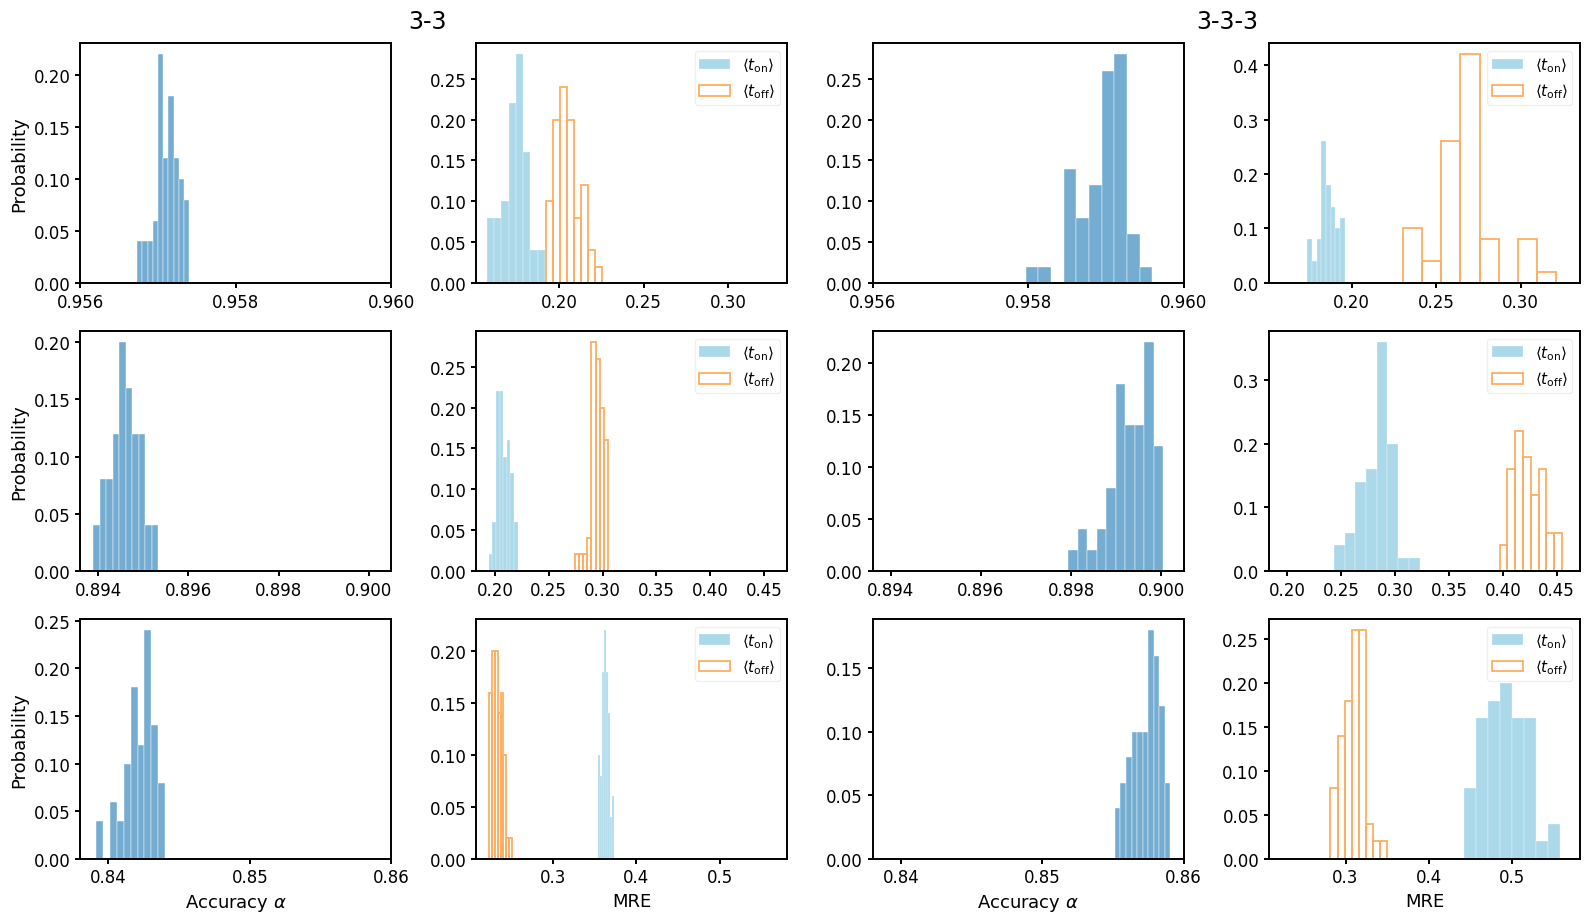

In [4]:
pad_ratio = 0.05  # 5% padding

function compute_lim(data)
    min_val, max_val = extrema(data)
    range_val = max_val - min_val
    return (min_val - range_val * pad_ratio, max_val + range_val * pad_ratio)
end

# Define multiple datasets dynamically
datasets = [
    ("b", accs_b33, accs_b333, res1_b33, res2_b33, res1_b333, res2_b333),
    ("nb1", accs_nb133, accs_nb1333, res1_nb133, res2_nb133, res1_nb1333, res2_nb1333),
    ("nb0", accs_nb033, accs_nb0333, res1_nb033, res2_nb033, res1_nb0333, res2_nb0333)
]

num_sets = length(datasets)
fig, axs = plt.subplots(num_sets, 4, figsize=(16, 3.0 * num_sets))  # Create subplots dynamically
plt.subplots_adjust(wspace=0.3)  # Increase horizontal space between columns

fs1 = 13
fs2 = 12
# Define plot properties with consistent tuple lengths
plot_types = [
    ("accuracy", 1, "#74add1", true),
    ("mean relative error", 2, ["on", "off"], false),
    ("accuracy", 3, "#74add1", false),
    ("mean relative error", 4, ["on", "off"], false)
]

for (row, (label, accs1, accs4, res1_1, res2_1, res1_4, res2_4)) in enumerate(datasets)
    # Compute x-axis limits for each dataset
    xlims = Dict(
        "accuracy" => compute_lim(vcat(accs1, accs4)),
        "mean relative error" => compute_lim(vcat(res1_1, res2_1, res1_4, res2_4))
    )

    # Define dataset mappings for plots
    dataset_map = Dict(
        1 => accs1, 2 => [("on", res1_1), ("off", res2_1)],
        3 => accs4, 4 => [("on", res1_4), ("off", res2_4)]
    )

    for (xlabel, i, color_type, ylabel) in plot_types
        ax = axs[row, i]  # Adjust indices for PyPlot
        data = dataset_map[i]
        
        if all(x -> isa(x, Tuple), data)  # Multiple histograms in one plot (res1, res2)
            for (dtype, d) in data
                if !isempty(d)
                    if dtype == "on"
                        counts, bins = np.histogram(d, bins=8)
                        ncounts = counts ./ sum(counts)
                        ax.bar(bins[1:end-1], ncounts, width=diff(bins), color="#abd9e9", edgecolor="white", lw=0.2, label=L"\langle t_\mathrm{on} \rangle");
    
                        #ax.hist(d, color="#abd9e9", bins=8, edgecolor="white", lw=0.2, alpha=0.8, label="mean on time")
                    elseif dtype == "off"
                        counts, bins = np.histogram(d, bins=8)
                        ncounts = counts ./ sum(counts)
                        ax.bar(bins[1:end-1], ncounts, width=diff(bins),  facecolor="none", edgecolor="#fdae61", lw=1.3, label=L"\langle t_\mathrm{off} \rangle");
    
                        #ax.hist(d, facecolor="none", edgecolor="#fdae61", lw=1.3, bins=8, label="mean off time")
                    end
                end
            end
            ax.legend(borderpad=0.3, fontsize=11, loc="upper right",framealpha=0.3)
        elseif isa(data, Vector)
            if !isempty(data)
                counts, bins = np.histogram(data, bins=10)
                ncounts = counts ./ sum(counts)
                ax.bar(bins[1:end-1], ncounts, width=diff(bins), color="#74add1", edgecolor="white", lw=0.3);
    
                #ax.hist(data, color=color_type, bins=10, edgecolor="black", lw=0.3)
            end
        end

        ax.set_xlim(xlims[xlabel])
        if ylabel
            ax.set_ylabel("Probability",fontsize=fs1)
        end
    end
end

axs[1,1].set_xlim(0.956,0.960)
axs[1,3].set_xlim(0.956,0.960)
axs[1,1].set_xticks([0.956,0.958,0.960]); axs[1,1].set_xticklabels(["0.956","0.958","0.960"])
axs[1,3].set_xticks([0.956,0.958,0.960]); axs[1,3].set_xticklabels(["0.956","0.958","0.960"])

axs[2,1].set_xlim(0.8936,0.9005)
axs[2,3].set_xlim(0.8936,0.9005)
axs[2,1].set_xticks([0.894,0.896,0.898,0.900]); axs[2,1].set_xticklabels(["0.894","0.896","0.898","0.900"])
axs[2,3].set_xticks([0.894,0.896,0.898,0.900]); axs[2,3].set_xticklabels(["0.894","0.896","0.898","0.900"])


axs[3,1].set_xlim(0.838,0.86)
axs[3,3].set_xlim(0.838,0.86)
axs[3,1].set_xticks([0.84,0.85,0.86]); axs[3,1].set_xticklabels(["0.84","0.85","0.86"])
axs[3,3].set_xticks([0.84,0.85,0.86]); axs[3,3].set_xticklabels(["0.84","0.85","0.86"])

axs[3,1].set_xlabel(L"Accuracy $\alpha$",fontsize=fs1) 
axs[3,2].set_xlabel("MRE",fontsize=fs1)
axs[3,3].set_xlabel(L"Accuracy $\alpha$",fontsize=fs1)
axs[3,4].set_xlabel("MRE",fontsize=fs1)

wd = 1.4
for i in 1:3
    for j in 1:4
        axs[i,j].tick_params(axis="both", labelsize=fs2, width=wd)
        for spine in values(axs[i,j].spines)
            spine.set_linewidth(wd)
        end
    end
end

fig.text(0.27, 1.0, "3-3", ha="center", fontsize=17)
fig.text(0.77, 1.0, "3-3-3", ha="center", fontsize=17)

plt.tight_layout()

fig.savefig("figs/compare_structure_plot.pdf", bbox_inches="tight")

#### Fig S2

In [5]:
# your three cases
(b1, nb1, nb01) = ("b33", "nb133", "nb033")

res_b1   = collect_metrics(b1; nseeds=100)
res_nb1  = collect_metrics(nb1; nseeds=100)
res_nb01 = collect_metrics(nb01; nseeds=100)

# keep your original variable names
accs_b1,   res1_b1,   res2_b1   = res_b1.accs,   res_b1.res1,   res_b1.res2
accs_nb1,  res1_nb1,  res2_nb1  = res_nb1.accs,  res_nb1.res1,  res_nb1.res2
accs_nb01, res1_nb01, res2_nb01 = res_nb01.accs, res_nb01.res1, res_nb01.res2;

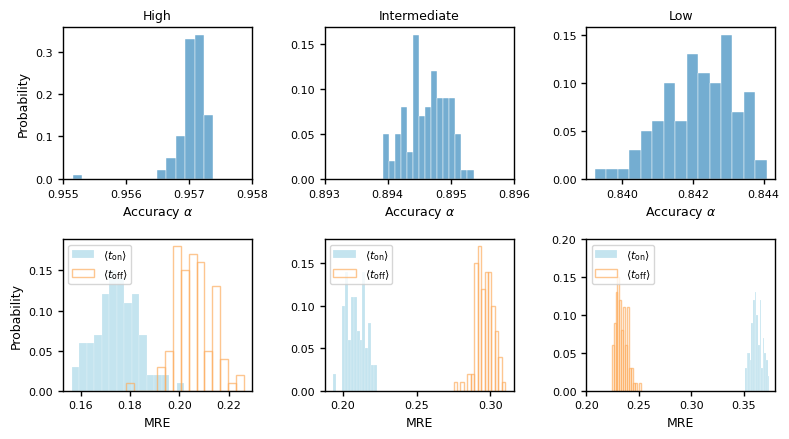

In [8]:
# Define data and labels
accs_all = [
    (accs_b1, L"Accuracy $\alpha$", (1, 1)),
    (accs_nb1, L"Accuracy $\alpha$", (1, 2)),
    (accs_nb01, L"Accuracy $\alpha$", (1, 3))
]

res_all = [
    (res1_b1, res2_b1, "MRE", (2, 1)),
    (res1_nb1, res2_nb1, "MRE", (2, 2)),
    (res1_nb01, res2_nb01, "MRE", (2, 3))
]

titles = ["High","Intermediate","Low"]

# Create figure and axes
fig, axs = plt.subplots(2, 3, figsize=(8, 4.5))
plt.subplots_adjust(wspace=0.2)

fs1 = 9
fs2 = 8
fs3 = 7

# Plot accuracy histograms 
for (data, xlabel, pos) in accs_all
    
    counts, bins, _ = hist(data, alpha=0, bins=15)
    ncounts = counts ./ sum(counts)
    axs[pos...].bar(bins[1:end-1],ncounts,width=diff(bins), lw=0.3, color="#74add1", edgecolor="white")
    
    #axs[pos...].hist(data, color="#74add1", edgecolor="black", lw=0.2, bins=20)
    axs[pos...].set_xlabel(xlabel,fontsize=fs1)
    axs[pos...].set_title(titles[pos[2]],fontsize=fs1)
    if pos == (1, 1)
        axs[pos...].set_ylabel("Probability",fontsize=fs1)
    end
end

# Plot mean relative error histograms
for (data1, data2, xlabel, pos) in res_all
    
    counts, bins, _ = hist(data1, alpha=0, bins=15)
    ncounts = counts ./ sum(counts)
    axs[pos...].bar(bins[1:end-1],ncounts,width=diff(bins), alpha=0.7, color="#abd9e9", edgecolor="white", lw=0.2, label=L"\langle t_\mathrm{on} \rangle")
    #axs[pos...].hist(data1, alpha=0.7, color="#abd9e9", edgecolor="white", lw=0.2, label="mean on time", bins=15)
    
    counts, bins, _ = hist(data2, alpha=0, bins=15)
    ncounts = counts ./ sum(counts)
    axs[pos...].bar(bins[1:end-1],ncounts,width=diff(bins), alpha=0.7, facecolor="none", edgecolor="#fdae61", lw=1.0, label=L"\langle t_\mathrm{off} \rangle")
    
    #axs[pos...].hist(data2, facecolor="none", edgecolor="#fdae61", lw=1.3, label="mean off time", bins=15)
    axs[pos...].set_xlabel(xlabel,fontsize=fs1)
    axs[pos...].legend(borderpad=0.3, fontsize=fs3, loc="upper left")
    if pos == (2, 1)
        axs[pos...].set_ylabel("Probability", fontsize=fs1)
    end
end

axs[1,1].set_xlim(0.955,0.958)
axs[1,1].set_xticks([0.955,0.956,0.957,0.958]); axs[1,1].set_xticklabels(["0.955","0.956","0.957","0.958"])

axs[1,2].set_xlim(0.893,0.896)
axs[1,2].set_xticks([0.893,0.894,0.895,0.896]); axs[1,2].set_xticklabels(["0.893","0.894","0.895","0.896"])

axs[2,3].set_ylim(0.0,0.2)
axs[2,3].set_xlim(0.2,0.38)

wd = 1.0
for i in 1:2
    for j in 1:3
        axs[i,j].tick_params(axis="both", labelsize=fs2, width=wd)
        for spine in values(axs[i,j].spines)
            spine.set_linewidth(wd)
        end
    end
end


plt.tight_layout()
fig.savefig("figs/posterior_plot.pdf", bbox_inches="tight")

#### seeds that have median performance

In [61]:
quantile_idx(res1_b1,0.5), quantile_idx(res2_b1,0.5), quantile_idx(accs_b1,0.5)

([60], [18], [58])

In [8]:
quantile_idx(res1_nb1,0.5), quantile_idx(res2_nb1,0.5), quantile_idx(accs_nb1,0.5)

([12], [18], [11])

In [9]:
quantile_idx(res1_nb01,0.5), quantile_idx(res2_nb01,0.5), quantile_idx(accs_nb01,0.5)

([73], [14], [49])